# Word2Vec — Semantic Analysis of Movie Reviews

This notebook trains a [gensim](https://radimrehurek.com/gensim/) Word2Vec model
on 25,000 movie reviews and explores the learned word embeddings. The reusable
preprocessing and training logic lives in the importable `src/` package, so the
notebook, the training script, and the Streamlit app all share one pipeline.

## 1. Setup

In [1]:
import os

from src.preprocessing import ensure_nltk_data, preprocess
from src.data import load_reviews, tokenize_reviews
from src.train import train_word2vec

# Download the NLTK resources we need, non-interactively (no-op if already present).
ensure_nltk_data()

## 2. Load and preprocess the reviews\n\nWe keep only the `review` text (Word2Vec is unsupervised, so the `sentiment` column is not needed). Preprocessing lower-cases, strips accents and HTML, and removes stop words and very short tokens.

In [2]:
reviews = load_reviews("MovieReview.csv")
print(f"Loaded {len(reviews):,} reviews")
print("Raw example:", reviews[0][:110], "...")

sentences = tokenize_reviews(reviews)
print("Tokenised example:", sentences[0][:12])

avg_len = sum(len(s) for s in sentences) / len(sentences)
print(f"Average tokens per review: {avg_len:.1f}")

Loaded 25,000 reviews
Raw example: With all this stuff going down at the moment with MJ i've started listening to his music, watching the odd doc ...


Tokenised example: ['stuff', 'going', 'moment', 'started', 'listening', 'music', 'watching', 'odd', 'documentary', 'watched', 'wiz', 'watched']
Average tokens per review: 118.0


## 3. Train the Word2Vec model\n\nWe use gensim's CBOW model. Hyper-parameters (vector size, window, epochs, seed) are fixed in `src/train.py` so the model is a reproducible object. `workers=4` speeds training up here; `src.train`'s default `workers=1` is fully deterministic.

In [3]:
model = train_word2vec("MovieReview.csv", workers=4)
wv = model.wv
print(f"Vocabulary size: {len(wv):,}")
print(f"Vector dimension: {wv.vector_size}")

Vocabulary size: 28,338
Vector dimension: 100


## 4. Explore the embeddings\n\n### Nearest neighbours\n\nThe most semantically similar words by cosine similarity.

In [4]:
for word in ["movie", "good", "terrible", "actor"]:
    neighbours = [w for w, _ in wv.most_similar(word, topn=6)]
    print(f"{word:10s} -> {', '.join(neighbours)}")

movie      -> film, flick, movies, thats, figured, really
good       -> decent, great, bad, nice, alright, okay
terrible   -> horrible, atrocious, awful, dreadful, abysmal, lousy
actor      -> actress, actors, pacino, role, roles, comedian


### Word analogies\n\nVector arithmetic such as *king − man + woman*. Note that reliable analogy solving needs a large, general corpus; on 25k movie reviews the results are indicative rather than perfect (issue #12 evaluates this quantitatively).

In [5]:
result = wv.most_similar(positive=["king", "woman"], negative=["man"], topn=3)
for w, score in result:
    print(f"{w:12s} {score:.3f}")

lion         0.494
triton       0.480
solomon      0.467


## 5. Evaluate the embeddings

Nearest neighbours look sensible, but let's quantify quality with a small,
corpus-appropriate analogy set and a similarity sanity check. Analogy accuracy on
25k movie reviews is necessarily modest — this is an honest, reproducible signal,
not a claim of state-of-the-art performance.

In [6]:
# A small curated analogy set (word1 : word2 :: word3 : ?), expected answer.
analogies = [
    ("man", "woman", "king", "queen"),
    ("bad", "worse", "good", "better"),
    ("act", "acting", "direct", "directing"),
    ("actor", "actress", "hero", "heroine"),
    ("one", "two", "three", "four"),
]
hits, evaluated = 0, 0
for a, b, c, expected in analogies:
    if not all(w in wv for w in (a, b, c, expected)):
        continue
    evaluated += 1
    predicted = [w for w, _ in wv.most_similar(positive=[b, c], negative=[a], topn=5)]
    ok = expected in predicted
    hits += ok
    print(f"{a}:{b} :: {c}:? -> {predicted[:3]}  (want '{expected}': {'HIT' if ok else 'miss'})")

coverage = evaluated / len(analogies)
accuracy = hits / evaluated if evaluated else 0.0
print(f"\nCoverage: {evaluated}/{len(analogies)} ({coverage:.0%}) | "
      f"Top-5 accuracy on covered: {accuracy:.0%}")

man:woman :: king:? -> ['lion', 'triton', 'solomon']  (want 'queen': miss)
bad:worse :: good:? -> ['better', 'funnier', 'decent']  (want 'better': HIT)
act:acting :: direct:? -> ['filmmaking', 'troma', 'directing']  (want 'directing': HIT)
actor:actress :: hero:? -> ['heroine', 'protagonist', 'antagonist']  (want 'heroine': HIT)
one:two :: three:? -> ['four', 'couple', 'several']  (want 'four': HIT)

Coverage: 5/5 (100%) | Top-5 accuracy on covered: 80%


In [7]:
# Similarity sanity check: sentiment words should cluster with the right pole.
for pos, neg in [("great", "terrible"), ("boring", "exciting")]:
    sim = wv.similarity(pos, neg)
    print(f"cosine('{pos}', '{neg}') = {sim:.3f}")
print("Nearest to 'oscar':", [w for w, _ in wv.most_similar('oscar', topn=5)])

cosine('great', 'terrible') = 0.407
cosine('boring', 'exciting') = 0.435
Nearest to 'oscar': ['award', 'nomination', 'oscars', 'nominated', 'nominations']


## 6. Visualise the embedding space

Project the most frequent words to 2-D with t-SNE. We run t-SNE on a small sample
(a few hundred vectors) rather than the full 28k vocabulary, which keeps it fast.

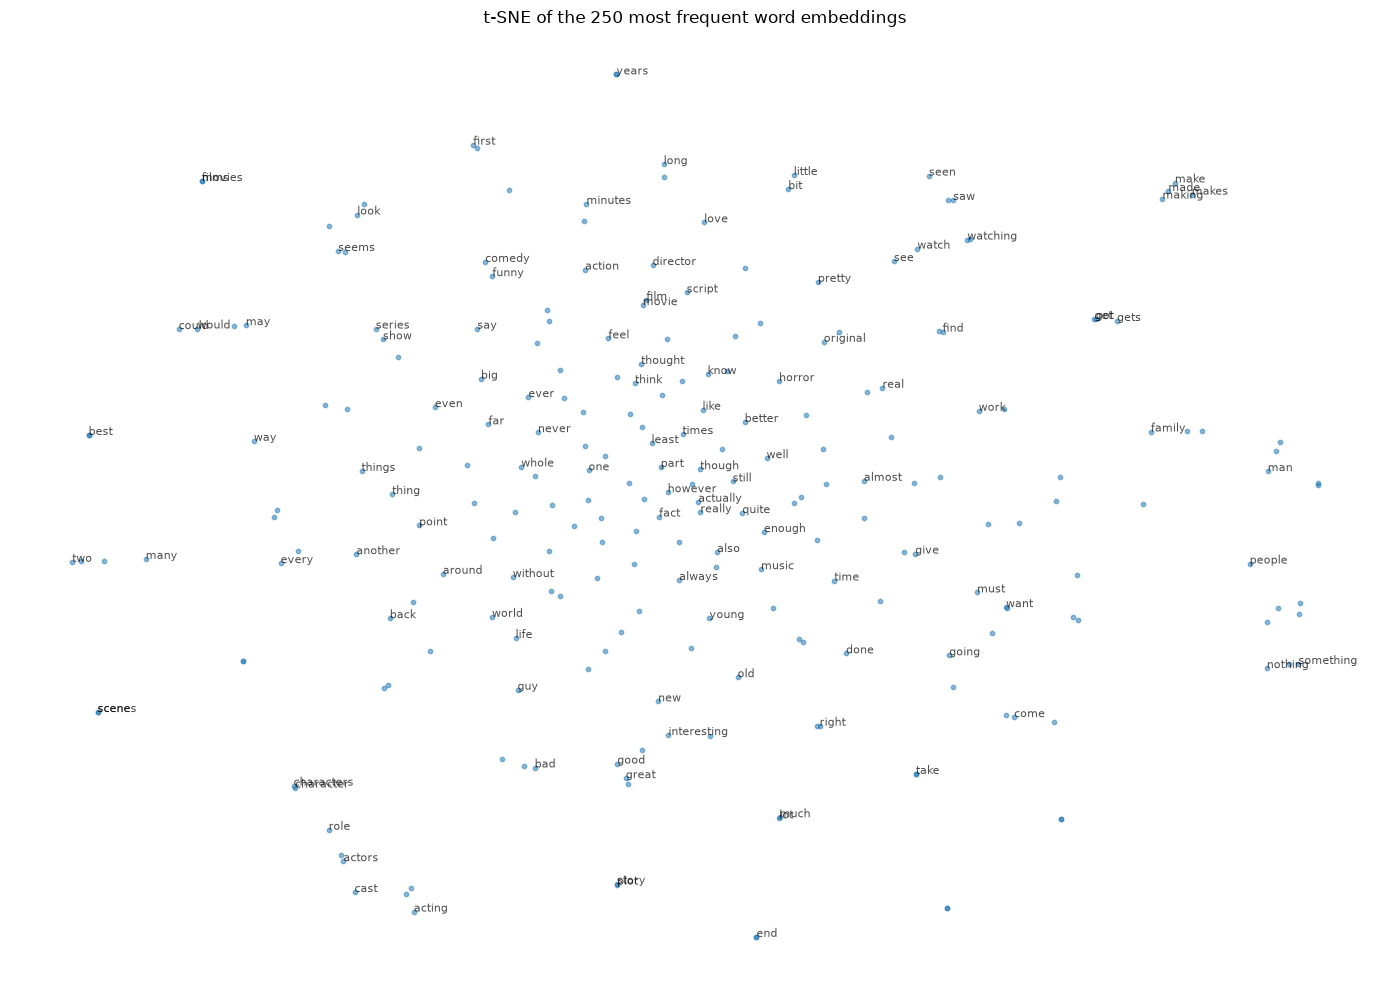

In [8]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

SAMPLE = 250  # keep t-SNE fast; do NOT run on the full vocabulary
words = wv.index_to_key[:SAMPLE]
vectors = wv[words]

coords = TSNE(n_components=2, random_state=42, init="pca",
              perplexity=15).fit_transform(vectors)

plt.figure(figsize=(14, 10))
plt.scatter(coords[:, 0], coords[:, 1], s=10, alpha=0.5)
for i, word in enumerate(words[:120]):  # label a readable subset
    plt.annotate(word, (coords[i, 0], coords[i, 1]), fontsize=8, alpha=0.7)
plt.title(f"t-SNE of the {SAMPLE} most frequent word embeddings")
plt.axis("off")
plt.tight_layout()
plt.show()

## 7. Interactive demo (`app.py`)

The trained vectors power a Streamlit app with the same two features (similarity
and analogies). Save the model and launch the app from the repo root:

```python
model.save("word2vec.model")
model.wv.save("word2vec.wv")
```

```bash
streamlit run app.py
```

`app.py` normalises user input through the same `src/` preprocessing used here,
so lookups always match the trained vocabulary.